<a href="https://colab.research.google.com/github/Avalya/Unified-PINN-Virtual-Sensors/blob/main/(PINN)_for_Pendulum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics-Informed Neural Network (PINN) for Pendulum Data Reconstruction

This notebook implements a PINN to reconstruct missing data points in a simulated pendulum dataset. The PINN leverages both the observed data and the known governing physics (the spring-mass pendulum equation) to achieve more robust reconstruction than purely data-driven methods.

### Overview of the Approach:
1.  **Setup and Imports**: Initialize necessary libraries and set up for reproducibility.
2.  **PINN Architecture**: Define the neural network structure, including a custom activation function.
3.  **Physics Loss**: Formulate a loss term based on the second-order ordinary differential equation (ODE) governing a simple spring-mass pendulum.
4.  **Data Loading and Preprocessing**: Load `pendulum_data.csv`, normalize the `Timestamp`, and identify training points.
5.  **Training Process**: Employ a two-phase optimization strategy (Adam followed by L-BFGS) to minimize a combined data and physics loss.
6.  **Visualization and Evaluation**: Plot the original and reconstructed data, and evaluate the reconstruction quality using NRMSE in the designated evaluation regions.

# 1. Initial Setup and Data Preparation

In [5]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [6]:
# 1. Physical constants from TAU_LR5 (Object 4)
m = 35.0  # kg
k = 271.0 # N/m

# Calculate T and K
T_period = np.sqrt(m / k)  # Time constant (not strictly period, but related to frequency)
K_gain = 1 / k

print(f"Calculated T (sqrt(m/k)): {T_period:.4f} s")
print(f"Calculated K (1/k): {K_gain:.7f}")

# 2. Generate time series
time_step = 0.055  # s (for consistency with robot data)
timestamp = np.arange(0, 10 + time_step, time_step)  # From 0 to 10s

# Calculate ideal displacement values x(t) = K * (1 - cos(t/T)) for transition characteristics
value_ideal = K_gain * (1 - np.cos(timestamp / T_period))

# Calculate analytical derivatives from ideal physical values
# x_ideal(t_phys) = K_gain * (1 - cos(t_phys / T_period))
# dx_ideal/dt_phys = K_gain * (1/T_period) * sin(t_phys / T_period)
# d2x_ideal/dt2_phys = K_gain * (1/T_period)^2 * cos(t_phys / T_period)

timestamp_phys = timestamp.flatten() # Use the generated timestamp for ideal derivatives

dx_dt_ideal = K_gain * (1/T_period) * np.sin(timestamp_phys / T_period)
d2x_dt2_ideal = K_gain * (1/T_period)**2 * np.cos(timestamp_phys / T_period)


# 3. Create DataFrame
df_generated = pd.DataFrame({
    'Timestamp': timestamp,
    'Value': value_ideal,
    'is_training': True
})

# Simulate sensor failure: break in data from 4.0 to 6.5 seconds
break_start = 4.0
break_end = 6.5

break_mask = (df_generated['Timestamp'] >= break_start) & (df_generated['Timestamp'] <= break_end)

df_generated.loc[break_mask, 'Value'] = np.nan
df_generated.loc[break_mask, 'is_training'] = False

# 4. Save the DataFrame to pendulum_data.csv
df_generated.to_csv('pendulum_data.csv', index=False)
print("\n'pendulum_data.csv' has been generated successfully.")

# Display the head of the generated DataFrame to confirm
print("\nGenerated DataFrame head:")
display(df_generated.head())
print("\nGenerated DataFrame tail:")
display(df_generated.tail())

Calculated T (sqrt(m/k)): 0.3594 s
Calculated K (1/k): 0.0036900

'pendulum_data.csv' has been generated successfully.

Generated DataFrame head:


,Timestamp,Value,is_training
0,0.000,0.000000,True
1,0.055,0.000043,True
2,0.110,0.000172,True
3,0.165,0.000382,True
4,0.220,0.000670,True



Generated DataFrame tail:


,Timestamp,Value,is_training
178,9.790,0.005581,True
179,9.845,0.006042,True
180,9.900,0.006448,True
181,9.955,0.006790,True
182,10.010,0.007059,True


In [7]:
# Load the dataset
df = pd.read_csv('pendulum_data.csv')

# Display the first few rows and info
print("Original DataFrame head:")
display(df.head())
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Columns:")
print(df.columns)

# Extract Timestamp and Value
timestamp_original = df['Timestamp'].values.reshape(-1, 1)
value_original = df['Value'].values.reshape(-1, 1)

# Normalize Timestamp to [0, 1]
scaler_t = MinMaxScaler()
t_normalized = scaler_t.fit_transform(timestamp_original)
t = torch.tensor(t_normalized, dtype=torch.float32, requires_grad=True)

# Normalize Value to [-1, 1]
scaler_x = MinMaxScaler(feature_range=(-1, 1))
x_normalized = scaler_x.fit_transform(value_original)
x_true_normalized_tensor = torch.tensor(x_normalized, dtype=torch.float32)

# Create a mask for training data (where is_training is True and Value is not NaN)
is_training_mask = df['is_training'].values

# Ensure that only non-NaN values contribute to data loss for training points
# When Value was NaN, x_normalized would also be NaN. So, filter those.
data_mask = is_training_mask & (~np.isnan(value_original).flatten())

t_data = t[data_mask]
x_data = x_true_normalized_tensor[data_mask] # Use normalized x_true for training

# Store the original scaling factors for time and value for derivative calculations
t_scale_factor = scaler_t.scale_[0] # This is 1 / (t_max - t_min)
x_scale_factor = scaler_x.scale_[0] # This is 2 / (x_max - x_min) for [-1,1] range
x_mean_phys = (scaler_x.data_max_[0] + scaler_x.data_min_[0]) / 2 # Mean of original physical values

# Define eval_mask here, as it's general data preparation for evaluation zones
eval_mask = ~is_training_mask # This identifies the region where is_training is False

print(f"\nNormalized time range: [{t.min():.4f}, {t.max():.4f}]")
print(f"Normalized value range for training data: [{x_data.min():.4f}, {x_data.max():.4f}]")
print(f"Number of data points for training: {len(t_data)}")
print(f"Time scaling factor for derivatives: {t_scale_factor:.4f}")
print(f"Value scaling factor for derivatives: {x_scale_factor:.4f}")
print(f"Physical mean of value for physics loss: {x_mean_phys:.6f}")

Original DataFrame head:


,Timestamp,Value,is_training
0,0.000,0.000000,True
1,0.055,0.000043,True
2,0.110,0.000172,True
3,0.165,0.000382,True
4,0.220,0.000670,True



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    183 non-null    float64
 1   Value        137 non-null    float64
 2   is_training  183 non-null    bool   
dtypes: bool(1), float64(2)
memory usage: 3.2 KB

DataFrame Columns:
Index(['Timestamp', 'Value', 'is_training'], dtype='object')

Normalized time range: [0.0000, 1.0000]
Normalized value range for training data: [-1.0000, 1.0000]
Number of data points for training: 137
Time scaling factor for derivatives: 0.0999
Value scaling factor for derivatives: 271.1499
Physical mean of value for physics loss: 0.003688


# 2. Model Architectures

## 2.1 PINN Architecture (8 Layers, 128 Neurons, Sin Activation)

In [8]:
class Sin(nn.Module):
    def forward(self, input):
        return torch.sin(input)

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            Sin(), # Custom Sine activation
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 1) # Output is 1D displacement
        )

        # Initialize weights using Xavier uniform initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)

# Instantiate the PINN model
pinn_model = PINN()
print("PINN model architecture (8 layers, 128 neurons, Sin activation):")
print(pinn_model)

PINN model architecture (8 layers, 128 neurons, Sin activation):
PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Sin()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Sin()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Sin()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Sin()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Sin()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Sin()
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): Sin()
    (14): Linear(in_features=128, out_features=128, bias=True)
    (15): Sin()
    (16): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 2.2 SimpleNN Architecture (8 Layers, 128 Neurons, ReLU Activation) - Baseline

In [9]:
class SimpleNN_ReLU(nn.Module):
    def __init__(self):
        super(SimpleNN_ReLU, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1) # Output is 1D displacement
        )

        # Initialize weights using Xavier uniform initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)

# Instantiate the SimpleNN_ReLU model
simple_model_relu = SimpleNN_ReLU()
print("Simple NN (with ReLU) model architecture (8 layers, 128 neurons):")
print(simple_model_relu)

Simple NN (with ReLU) model architecture (8 layers, 128 neurons):
SimpleNN_ReLU(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): ReLU()
    (14): Linear(in_features=128, out_features=128, bias=True)
    (15): ReLU()
    (16): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 2.3 SimpleNN Architecture (8 Layers, 128 Neurons, Tanh Activation)

In [10]:
class SimpleNN_Tanh(nn.Module):
    def __init__(self):
        super(SimpleNN_Tanh, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1) # Output is 1D displacement
        )

        # Initialize weights using Xavier uniform initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)

# Instantiate the SimpleNN_Tanh model
simple_model_tanh = SimpleNN_Tanh()
print("Simple NN (with Tanh) model architecture (8 layers, 128 neurons):")
print(simple_model_tanh)

Simple NN (with Tanh) model architecture (8 layers, 128 neurons):
SimpleNN_Tanh(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): Tanh()
    (14): Linear(in_features=128, out_features=128, bias=True)
    (15): Tanh()
    (16): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 2.4 SimpleNN Architecture (8 Layers, 128 Neurons, Sin Activation)

In [11]:
class SimpleNN_Sin(nn.Module):
    def __init__(self):
        super(SimpleNN_Sin, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 128),
            Sin(),
            nn.Linear(128, 1) # Output is 1D displacement
        )

        # Initialize weights using Xavier uniform initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)

# Instantiate the SimpleNN_Sin model
simple_model_sin = SimpleNN_Sin()
print("Simple NN (with Sin) model architecture (8 layers, 128 neurons):")
print(simple_model_sin)

Simple NN (with Sin) model architecture (8 layers, 128 neurons):
SimpleNN_Sin(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Sin()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Sin()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Sin()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Sin()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Sin()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Sin()
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): Sin()
    (14): Linear(in_features=128, out_features=128, bias=True)
    (15): Sin()
    (16): Linear(in_features=128, out_features=1, bias=True)
  )
)


# 3. Helper Functions

In [12]:
# 3.1 Physics Loss Function
# Physical constants (from ITMO lab works)
# These are already defined in the data generation step, but re-defining for clarity or if cell is run independently
m = 35.0  # kg
k = 271.0 # N/m

def physics_loss(model, t, t_scale_factor, x_scale_factor, x_mean_phys):
    # Predict x (normalized) at time t (normalized)
    x_norm = model(t)

    # Compute first derivative dx_norm/dt_norm
    dx_dt_norm = torch.autograd.grad(
        x_norm,
        t,
        grad_outputs=torch.ones_like(x_norm),
        create_graph=True,
        retain_graph=True
    )[0]

    # Convert normalized derivative to physical velocity
    # dx_phys/dt_phys = (dx_norm/dt_norm) * (x_range / t_range)
    # where x_range = 1/x_scale_factor_current and t_range = 1/t_scale_factor
    # So (x_range / t_range) = (t_scale_factor / x_scale_factor)
    dx_dt_phys = dx_dt_norm * (t_scale_factor / x_scale_factor)

    # Compute second derivative d2x_norm/dt_norm2
    d2x_dt2_norm = torch.autograd.grad(
        dx_dt_norm,
        t,
        grad_outputs=torch.ones_like(dx_dt_norm),
        create_graph=True,
        retain_graph=True
    )[0]

    # Convert normalized second derivative to physical acceleration
    # d2x_phys/dt_phys^2 = (d2x_norm/dt_norm^2) * (x_range / t_range^2)
    # So (x_range / t_range^2) = (t_scale_factor^2 / x_scale_factor)
    d2x_dt2_phys = d2x_dt2_norm * (t_scale_factor ** 2 / x_scale_factor)

    # Physics-informed residual: m*x'' + k*x = 0
    # x_phys = x_norm / x_scale_factor + x_mean_phys (for [-1,1] normalization)
    residual = m * d2x_dt2_phys + k * (x_norm / x_scale_factor + x_mean_phys)
    return torch.mean(residual**2)

In [13]:
# 3.2 Dynamic Physics Loss Weighting Function
def get_physics_loss_weight(epoch, total_epochs, initial_physics_weight, final_physics_weight, start_epoch_annealing=0):
    if epoch < start_epoch_annealing:
        return initial_physics_weight

    annealing_epochs = total_epochs - start_epoch_annealing
    if annealing_epochs <= 0:
        return final_physics_weight

    progress = min(1.0, (epoch - start_epoch_annealing) / annealing_epochs)

    current_weight = initial_physics_weight + progress * (final_physics_weight - initial_physics_weight)

    return current_weight

In [14]:
# 3.3 Simple NN Training Function
def train_simple_nn(model, t_data, x_data, epochs=1000):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    print("--- Starting Simple NN Training ---")
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Clone and detach t_data to create a new computational graph for each epoch
        t_data_for_loss = t_data.clone().detach().requires_grad_(True)

        x_pred_data = model(t_data_for_loss)
        loss = torch.mean((x_pred_data - x_data)**2) # Only data loss

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0:
            print(f"Simple NN Epoch {epoch+1}/{epochs}, Data Loss: {loss.item():.6f}")
    print("Simple NN Training Finished.")

In [15]:
# 3.4 PINN Training Function
def train_pinn(model, t, t_data, x_data, t_scale_factor, x_scale_factor, x_mean_phys, epochs_adam=2000,
                 initial_physics_weight=0.05, final_physics_weight=1.0, start_epoch_annealing=0):
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=50000, history_size=50, line_search_fn="strong_wolfe")

    # Store loss history
    total_loss_history = []
    data_loss_history = []
    physics_loss_history = []
    physics_weight_history = []

    print("---> Starting Adam Training with Dynamic Loss Weighting ---")
    for epoch in range(epochs_adam):
        model.train()
        optimizer_adam.zero_grad()

        current_physics_loss_weight = get_physics_loss_weight(
            epoch, epochs_adam, initial_physics_weight, final_physics_weight, start_epoch_annealing
        )
        physics_weight_history.append(current_physics_loss_weight)


        t_data_for_loss = t_data.clone().detach().requires_grad_(True)
        t_for_physics = t.clone().detach().requires_grad_(True)

        # Data Loss: only on available training data
        x_pred_data = model(t_data_for_loss)
        loss_data = torch.mean((x_pred_data - x_data)**2)

        # Physics Loss: on the entire time domain
        loss_physics = physics_loss(model, t_for_physics, t_scale_factor, x_scale_factor, x_mean_phys)

        # Total Loss with dynamic weighting
        loss = loss_data + current_physics_loss_weight * loss_physics

        loss.backward()
        optimizer_adam.step()

        total_loss_history.append(loss.item())
        data_loss_history.append(loss_data.item())
        physics_loss_history.append(loss_physics.item())

        if (epoch + 1) % 100 == 0:
            print(f"Adam Epoch {epoch+1}/{epochs_adam}, Total Loss: {loss.item():.6f}, Data Loss: {loss_data.item():.6f}, Physics Loss: {loss_physics.item():.6f}, Phys Weight: {current_physics_loss_weight:.4f}")

    print("\n---> Starting L-BFGS Training ---")
    # For L-BFGS, we'll use the final physics weight from the Adam phase
    final_physics_weight_for_lbfgs = physics_weight_history[-1] if physics_weight_history else final_physics_weight

    def closure():
        optimizer_lbfgs.zero_grad()

        t_data_for_loss = t_data.clone().detach().requires_grad_(True)
        t_for_physics = t.clone().detach().requires_grad_(True)

        # Data Loss
        x_pred_data = model(t_data_for_loss)
        loss_data = torch.mean((x_pred_data - x_data)**2)

        # Physics Loss
        loss_physics = physics_loss(model, t_for_physics, t_scale_factor, x_scale_factor, x_mean_phys)

        loss = loss_data + final_physics_weight_for_lbfgs * loss_physics

        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    # Calculate final loss after L-BFGS
    model.eval() # Switch to evaluation mode for final loss calculation

    with torch.no_grad():
        x_pred_data_final = model(t_data)
        loss_data_final = torch.mean((x_pred_data_final - x_data)**2)

    t_for_physics_final = t.clone().detach().requires_grad_(True)
    loss_physics_final = physics_loss(model, t_for_physics_final, t_scale_factor, x_scale_factor, x_mean_phys)

    with torch.no_grad():
        final_loss = loss_data_final + final_physics_weight_for_lbfgs * loss_physics_final

    model.train() # Set back to train mode in case of further training or operations

    print(f"L-BFGS Training Finished. Final Total Loss: {final_loss.item():.6f}")

    return total_loss_history, data_loss_history, physics_loss_history, physics_weight_history

# 4. Model Training and Evaluation

## 4.1 PINN Model Training and Evaluation

In [16]:
# Re-initialize the PINN model to ensure a fresh training run
pinn_model = PINN()

epochs_adam_dynamic = 2000 # Number of Adam epochs
initial_physics_weight_dynamic = 0.01 # Start with a small weight for physics loss
final_physics_weight_dynamic = 1.0    # End with a higher weight
start_annealing_epoch = 0   # Start annealing from epoch 0

print("\n--- Training PINN Model ---")
pinn_total_loss_history, pinn_data_loss_history, pinn_physics_loss_history, pinn_physics_weight_history = train_pinn(
    pinn_model, t, t_data, x_data, t_scale_factor, x_scale_factor, x_mean_phys,
    epochs_adam=epochs_adam_dynamic,
    initial_physics_weight=initial_physics_weight_dynamic,
    final_physics_weight=final_physics_weight_dynamic,
    start_epoch_annealing=start_annealing_epoch
)

# Set model to evaluation mode
pinn_model.eval()

print("\n--- Evaluating PINN Model ---")
# --- NRMSE Calculation for PINN in the 'zone of omissions' ---
with torch.no_grad():
    x_pred_normalized_pinn = pinn_model(t).cpu().numpy()
x_pred_pinn = scaler_x.inverse_transform(x_pred_normalized_pinn)

if np.sum(eval_mask) > 0:
    x_true_eval_pinn = value_ideal[eval_mask]
    x_pred_eval_pinn = x_pred_pinn.flatten()[eval_mask]

    rmse_pinn = np.sqrt(mean_squared_error(x_true_eval_pinn, x_pred_eval_pinn))
    range_x_true_eval_pinn = np.max(x_true_eval_pinn) - np.min(x_true_eval_pinn)

    if range_x_true_eval_pinn > 0:
        nrmse_pinn = rmse_pinn / range_x_true_eval_pinn
        print(f"NRMSE для зоны пропуска (PINN): {nrmse_pinn:.4f}")
    else:
        print("Невозможно рассчитать NRMSE для PINN: диапазон истинных значений в оценочной зоне равен нулю.")
else:
    print("Отсутствуют точки для оценки в зоне пропуска для PINN.")

# --- Calculate derivatives for PINN output and MSE ---
t_for_deriv_pinn = t.clone().detach().requires_grad_(True)
x_pinn_norm = pinn_model(t_for_deriv_pinn)

dx_dt_norm_pinn = torch.autograd.grad(
    x_pinn_norm,
    t_for_deriv_pinn,
    grad_outputs=torch.ones_like(x_pinn_norm),
    create_graph=True,
    retain_graph=True
)[0]
dx_dt_pinn = dx_dt_norm_pinn * (t_scale_factor / x_scale_factor)

d2x_dt2_norm_pinn = torch.autograd.grad(
    dx_dt_norm_pinn,
    t_for_deriv_pinn,
    grad_outputs=torch.ones_like(dx_dt_norm_pinn),
    create_graph=True,
    retain_graph=True
)[0]
d2x_dt2_pinn = d2x_dt2_norm_pinn * (t_scale_factor ** 2 / x_scale_factor)

dx_dt_pinn_np = dx_dt_pinn.detach().cpu().numpy().flatten()
d2x_dt2_pinn_np = d2x_dt2_pinn.detach().cpu().numpy().flatten()

mse_dx_dt_pinn = mean_squared_error(dx_dt_ideal, dx_dt_pinn_np)
print(f"MSE для первой производной (скорость, PINN): {mse_dx_dt_pinn:.8f}")

mse_d2x_dt2_pinn = mean_squared_error(d2x_dt2_ideal, d2x_dt2_pinn_np)
print(f"MSE для второй производной (ускорение, PINN): {mse_d2x_dt2_pinn:.8f}")


--- Training PINN Model ---
---> Starting Adam Training with Dynamic Loss Weighting ---
Adam Epoch 100/2000, Total Loss: 0.558353, Data Loss: 0.506052, Physics Loss: 0.886384, Phys Weight: 0.0590
Adam Epoch 200/2000, Total Loss: 0.600199, Data Loss: 0.512520, Physics Loss: 0.808066, Phys Weight: 0.1085
Adam Epoch 300/2000, Total Loss: 0.638474, Data Loss: 0.521478, Physics Loss: 0.740455, Phys Weight: 0.1580
Adam Epoch 400/2000, Total Loss: 0.673614, Data Loss: 0.532304, Physics Loss: 0.680997, Phys Weight: 0.2075
Adam Epoch 500/2000, Total Loss: 0.705981, Data Loss: 0.544486, Physics Loss: 0.628372, Phys Weight: 0.2570
Adam Epoch 600/2000, Total Loss: 0.736419, Data Loss: 0.550906, Physics Loss: 0.605252, Phys Weight: 0.3065
Adam Epoch 700/2000, Total Loss: 0.763675, Data Loss: 0.571266, Physics Loss: 0.540468, Phys Weight: 0.3560
Adam Epoch 800/2000, Total Loss: 0.789434, Data Loss: 0.585563, Physics Loss: 0.502760, Phys Weight: 0.4055
Adam Epoch 900/2000, Total Loss: 0.813568, Data

## 4.2 SimpleNN (ReLU) Model Training and Evaluation

In [ ]:
# Re-initialize the SimpleNN_ReLU model
simple_model_relu = SimpleNN_ReLU()

print("\n--- Training SimpleNN (ReLU) Model ---")
train_simple_nn(simple_model_relu, t_data, x_data, epochs=1000)

# Set model to evaluation mode
simple_model_relu.eval()

print("\n--- Evaluating SimpleNN (ReLU) Model ---")
# --- NRMSE Calculation for SimpleNN_ReLU in the 'zone of omissions' ---
with torch.no_grad():
    x_pred_normalized_relu = simple_model_relu(t).cpu().numpy()
x_pred_relu = scaler_x.inverse_transform(x_pred_normalized_relu)

if np.sum(eval_mask) > 0:
    x_true_eval_relu = value_ideal[eval_mask]
    x_pred_eval_relu = x_pred_relu.flatten()[eval_mask]

    rmse_relu = np.sqrt(mean_squared_error(x_true_eval_relu, x_pred_eval_relu))
    range_x_true_eval_relu = np.max(x_true_eval_relu) - np.min(x_true_eval_relu)

    if range_x_true_eval_relu > 0:
        nrmse_relu = rmse_relu / range_x_true_eval_relu
        print(f"NRMSE для зоны пропуска (SimpleNN_ReLU): {nrmse_relu:.4f}")
    else:
        print("Невозможно рассчитать NRMSE для SimpleNN_ReLU: диапазон истинных значений в оценочной зоне равен нулю.")
else:
    print("Отсутствуют точки для оценки в зоне пропуска для SimpleNN_ReLU.")

# --- Calculate derivatives for SimpleNN_ReLU output and MSE ---
t_for_deriv_relu = t.clone().detach().requires_grad_(True)
x_relu_norm = simple_model_relu(t_for_deriv_relu)

dx_dt_norm_relu = torch.autograd.grad(
    x_relu_norm,
    t_for_deriv_relu,
    grad_outputs=torch.ones_like(x_relu_norm),
    create_graph=True,
    retain_graph=True
)[0]
dx_dt_relu = dx_dt_norm_relu * (t_scale_factor / x_scale_factor)

d2x_dt2_norm_relu = torch.autograd.grad(
    dx_dt_norm_relu,
    t_for_deriv_relu,
    grad_outputs=torch.ones_like(dx_dt_norm_relu),
    create_graph=True,
    retain_graph=True
)[0]
d2x_dt2_relu = d2x_dt2_norm_relu * (t_scale_factor ** 2 / x_scale_factor)

dx_dt_relu_np = dx_dt_relu.detach().cpu().numpy().flatten()
d2x_dt2_relu_np = d2x_dt2_relu.detach().cpu().numpy().flatten()

mse_dx_dt_relu = mean_squared_error(dx_dt_ideal, dx_dt_relu_np)
print(f"MSE для первой производной (скорость, SimpleNN_ReLU): {mse_dx_dt_relu:.8f}")

mse_d2x_dt2_relu = mean_squared_error(d2x_dt2_ideal, d2x_dt2_relu_np)
print(f"MSE для второй производной (ускорение, SimpleNN_ReLU): {mse_d2x_dt2_relu:.8f}")


--- Training SimpleNN (ReLU) Model ---
--- Starting Simple NN Training ---
Simple NN Epoch 100/1000, Data Loss: 0.238147
Simple NN Epoch 200/1000, Data Loss: 0.223120
Simple NN Epoch 300/1000, Data Loss: 0.195639
Simple NN Epoch 400/1000, Data Loss: 0.114375
Simple NN Epoch 500/1000, Data Loss: 0.007267
Simple NN Epoch 600/1000, Data Loss: 0.003104
Simple NN Epoch 700/1000, Data Loss: 0.000345
Simple NN Epoch 800/1000, Data Loss: 0.000285
Simple NN Epoch 900/1000, Data Loss: 0.000250
Simple NN Epoch 1000/1000, Data Loss: 0.000368
Simple NN Training Finished.

--- Evaluating SimpleNN (ReLU) Model ---
NRMSE для зоны пропуска (SimpleNN_ReLU): 0.5449
MSE для первой производной (скорость, SimpleNN_ReLU): 0.00001498
MSE для второй производной (ускорение, SimpleNN_ReLU): 0.00040463


## 4.3 SimpleNN (Tanh) Model Training and Evaluation

In [ ]:
# Re-initialize the SimpleNN_Tanh model
simple_model_tanh = SimpleNN_Tanh()

print("\n--- Training SimpleNN (Tanh) Model ---")
train_simple_nn(simple_model_tanh, t_data, x_data, epochs=1000)

# Set model to evaluation mode
simple_model_tanh.eval()

print("\n--- Evaluating SimpleNN (Tanh) Model ---")
# --- NRMSE Calculation for SimpleNN_Tanh in the 'zone of omissions' ---
with torch.no_grad():
    x_pred_normalized_tanh = simple_model_tanh(t).cpu().numpy()
x_pred_tanh = scaler_x.inverse_transform(x_pred_normalized_tanh)

if np.sum(eval_mask) > 0:
    x_true_eval_tanh = value_ideal[eval_mask]
    x_pred_eval_tanh = x_pred_tanh.flatten()[eval_mask]

    rmse_tanh = np.sqrt(mean_squared_error(x_true_eval_tanh, x_pred_eval_tanh))
    range_x_true_eval_tanh = np.max(x_true_eval_tanh) - np.min(x_true_eval_tanh)

    if range_x_true_eval_tanh > 0:
        nrmse_tanh = rmse_tanh / range_x_true_eval_tanh
        print(f"NRMSE для зоны пропуска (SimpleNN_Tanh): {nrmse_tanh:.4f}")
    else:
        print("Невозможно рассчитать NRMSE для SimpleNN_Tanh: диапазон истинных значений в оценочной зоне равен нулю.")
else:
    print("Отсутствуют точки для оценки в зоне пропуска для SimpleNN_Tanh.")

# --- Calculate derivatives for SimpleNN_Tanh output and MSE ---
t_for_deriv_tanh = t.clone().detach().requires_grad_(True)
x_tanh_norm = simple_model_tanh(t_for_deriv_tanh)

dx_dt_norm_tanh = torch.autograd.grad(
    x_tanh_norm,
    t_for_deriv_tanh,
    grad_outputs=torch.ones_like(x_tanh_norm),
    create_graph=True,
    retain_graph=True
)[0]
dx_dt_tanh = dx_dt_norm_tanh * (t_scale_factor / x_scale_factor)

d2x_dt2_norm_tanh = torch.autograd.grad(
    dx_dt_norm_tanh,
    t_for_deriv_tanh,
    grad_outputs=torch.ones_like(dx_dt_norm_tanh),
    create_graph=True,
    retain_graph=True
)[0]
d2x_dt2_tanh = d2x_dt2_norm_tanh * (t_scale_factor ** 2 / x_scale_factor)

dx_dt_tanh_np = dx_dt_tanh.detach().cpu().numpy().flatten()
d2x_dt2_tanh_np = d2x_dt2_tanh.detach().cpu().numpy().flatten()

mse_dx_dt_tanh = mean_squared_error(dx_dt_ideal, dx_dt_tanh_np)
print(f"MSE для первой производной (скорость, SimpleNN_Tanh): {mse_dx_dt_tanh:.8f}")

mse_d2x_dt2_tanh = mean_squared_error(d2x_dt2_ideal, d2x_dt2_tanh_np)
print(f"MSE для второй производной (ускорение, SimpleNN_Tanh): {mse_d2x_dt2_tanh:.8f}")


--- Training SimpleNN (Tanh) Model ---
--- Starting Simple NN Training ---
Simple NN Epoch 100/1000, Data Loss: 0.503076
Simple NN Epoch 200/1000, Data Loss: 0.503069
Simple NN Epoch 300/1000, Data Loss: 0.503056
Simple NN Epoch 400/1000, Data Loss: 0.503021
Simple NN Epoch 500/1000, Data Loss: 0.503117
Simple NN Epoch 600/1000, Data Loss: 0.504169
Simple NN Epoch 700/1000, Data Loss: 0.502790
Simple NN Epoch 800/1000, Data Loss: 0.502366
Simple NN Epoch 900/1000, Data Loss: 0.501810
Simple NN Epoch 1000/1000, Data Loss: 0.501449
Simple NN Training Finished.

--- Evaluating SimpleNN (Tanh) Model ---
NRMSE для зоны пропуска (SimpleNN_Tanh): 0.3473
MSE для первой производной (скорость, SimpleNN_Tanh): 0.00005324
MSE для второй производной (ускорение, SimpleNN_Tanh): 0.00040464


## 4.4 SimpleNN (Sin) Model Training and Evaluation

In [ ]:
# Re-initialize the SimpleNN_Sin model
simple_model_sin = SimpleNN_Sin()

print("\n--- Training SimpleNN (Sin) Model ---")
train_simple_nn(simple_model_sin, t_data, x_data, epochs=1000)

# Set model to evaluation mode
simple_model_sin.eval()

print("\n--- Evaluating SimpleNN (Sin) Model ---")
# --- NRMSE Calculation for SimpleNN_Sin in the 'zone of omissions' ---
with torch.no_grad():
    x_pred_normalized_sin = simple_model_sin(t).cpu().numpy()
x_pred_sin = scaler_x.inverse_transform(x_pred_normalized_sin)

if np.sum(eval_mask) > 0:
    x_true_eval_sin = value_ideal[eval_mask]
    x_pred_eval_sin = x_pred_sin.flatten()[eval_mask]

    rmse_sin = np.sqrt(mean_squared_error(x_true_eval_sin, x_pred_eval_sin))
    range_x_true_eval_sin = np.max(x_true_eval_sin) - np.min(x_true_eval_sin)

    if range_x_true_eval_sin > 0:
        nrmse_sin = rmse_sin / range_x_true_eval_sin
        print(f"NRMSE для зоны пропуска (SimpleNN_Sin): {nrmse_sin:.4f}")
    else:
        print("Невозможно рассчитать NRMSE для SimpleNN_Sin: диапазон истинных значений в оценочной зоне равен нулю.")
else:
    print("Отсутствуют точки для оценки в зоне пропуска для SimpleNN_Sin.")

# --- Calculate derivatives for SimpleNN_Sin output and MSE ---
t_for_deriv_sin = t.clone().detach().requires_grad_(True)
x_sin_norm = simple_model_sin(t_for_deriv_sin)

dx_dt_norm_sin = torch.autograd.grad(
    x_sin_norm,
    t_for_deriv_sin,
    grad_outputs=torch.ones_like(x_sin_norm),
    create_graph=True,
    retain_graph=True
)[0]
dx_dt_sin = dx_dt_norm_sin * (t_scale_factor / x_scale_factor)

d2x_dt2_norm_sin = torch.autograd.grad(
    dx_dt_norm_sin,
    t_for_deriv_sin,
    grad_outputs=torch.ones_like(dx_dt_norm_sin),
    create_graph=True,
    retain_graph=True
)[0]
d2x_dt2_sin = d2x_dt2_norm_sin * (t_scale_factor ** 2 / x_scale_factor)

dx_dt_sin_np = dx_dt_sin.detach().cpu().numpy().flatten()
d2x_dt2_sin_np = d2x_dt2_sin.detach().cpu().numpy().flatten()

mse_dx_dt_sin = mean_squared_error(dx_dt_ideal, dx_dt_sin_np)
print(f"MSE для первой производной (скорость, SimpleNN_Sin): {mse_dx_dt_sin:.8f}")

mse_d2x_dt2_sin = mean_squared_error(d2x_dt2_ideal, d2x_dt2_sin_np)
print(f"MSE для второй производной (ускорение, SimpleNN_Sin): {mse_d2x_dt2_sin:.8f}")


--- Training SimpleNN (Sin) Model ---
--- Starting Simple NN Training ---
Simple NN Epoch 100/1000, Data Loss: 0.503075
Simple NN Epoch 200/1000, Data Loss: 0.503070
Simple NN Epoch 300/1000, Data Loss: 0.503065
Simple NN Epoch 400/1000, Data Loss: 0.503059
Simple NN Epoch 500/1000, Data Loss: 0.503050
Simple NN Epoch 600/1000, Data Loss: 0.503031
Simple NN Epoch 700/1000, Data Loss: 0.502934
Simple NN Epoch 800/1000, Data Loss: 0.503060
Simple NN Epoch 900/1000, Data Loss: 0.503044
Simple NN Epoch 1000/1000, Data Loss: 0.503021
Simple NN Training Finished.

--- Evaluating SimpleNN (Sin) Model ---
NRMSE для зоны пропуска (SimpleNN_Sin): 0.3455
MSE для первой производной (скорость, SimpleNN_Sin): 0.00005323
MSE для второй производной (ускорение, SimpleNN_Sin): 0.00040463


### Phase Portrait for SimpleNN (Sin)

'simple_model_sin' already defined. Proceeding with plotting.


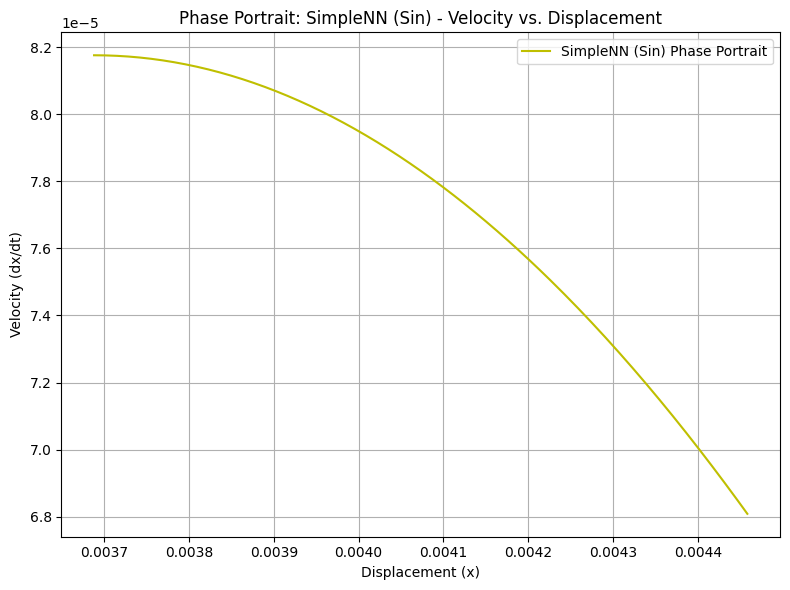

In [17]:
import matplotlib.pyplot as plt

# --- Begin added code to ensure simple_model_sin is defined and trained for this plot ---
# This block assumes SimpleNN_Sin class, Sin class, and train_simple_nn function,
# as well as data variables (t, t_data, x_data, scaler_x, t_scale_factor, x_scale_factor)
# have been defined by running previous cells in the notebook.
if 'simple_model_sin' not in locals() and 'simple_model_sin' not in globals():
    print("WARNING: 'simple_model_sin' was not found in the current session. Re-instantiating and re-training the model for plotting. This may be redundant if the previous training cell was executed.")
    # Re-initialize the SimpleNN_Sin model
    simple_model_sin = SimpleNN_Sin()
    # Train the model (assuming t_data, x_data, and train_simple_nn are available)
    train_simple_nn(simple_model_sin, t_data, x_data, epochs=1000)
else:
    print("'simple_model_sin' already defined. Proceeding with plotting.")
# --- End added code ---

# Ensure model is in evaluation mode
simple_model_sin.eval()

# Calculate x_pred_sin_denorm
with torch.no_grad():
    x_pred_normalized_sin = simple_model_sin(t).cpu().numpy()
x_pred_sin_denorm = scaler_x.inverse_transform(x_pred_normalized_sin)

# Calculate dx_dt_sin_np (velocity)
t_for_deriv_sin = t.clone().detach().requires_grad_(True)
x_sin_norm = simple_model_sin(t_for_deriv_sin)

dx_dt_norm_sin = torch.autograd.grad(
    x_sin_norm,
    t_for_deriv_sin,
    grad_outputs=torch.ones_like(x_sin_norm),
    create_graph=True,
    retain_graph=True
)[0]
dx_dt_sin = dx_dt_norm_sin * (t_scale_factor / x_scale_factor)
dx_dt_sin_np = dx_dt_sin.detach().cpu().numpy().flatten()

plt.figure(figsize=(8, 6))
plt.plot(x_pred_sin_denorm, dx_dt_sin_np, 'y-', label='SimpleNN (Sin) Phase Portrait', linewidth=1.5)
plt.title('Phase Portrait: SimpleNN (Sin) - Velocity vs. Displacement')
plt.xlabel('Displacement (x)')
plt.ylabel('Velocity (dx/dt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Consolidated Visualizations


--- Generating Consolidated Visualizations ---


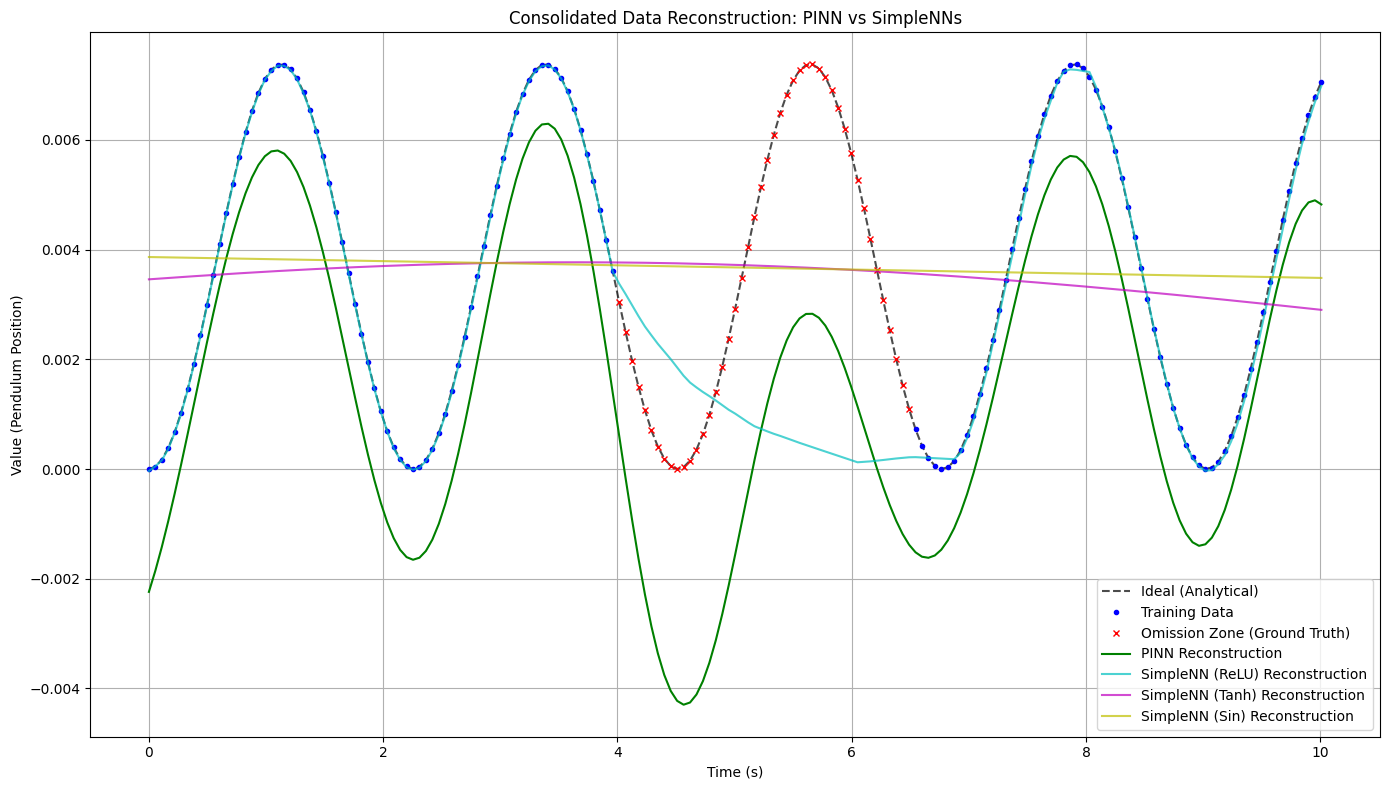

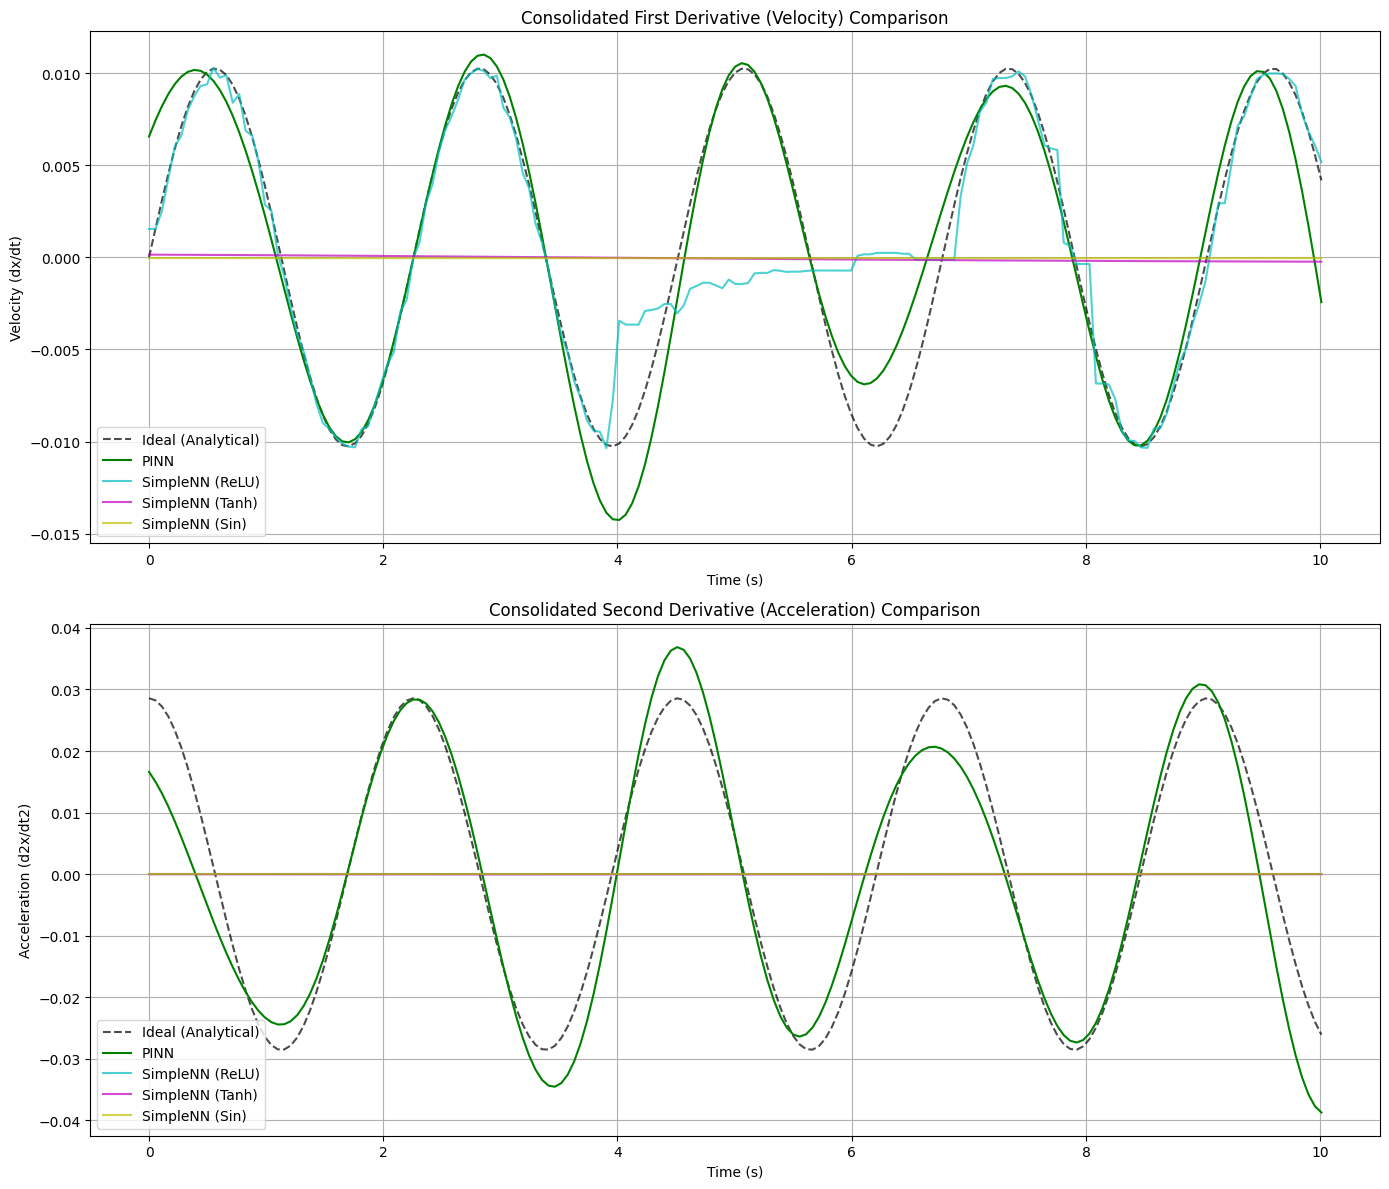

In [ ]:
print("\n--- Generating Consolidated Visualizations ---")

# --- Denormalize predictions for plotting ---
x_pred_pinn_denorm = scaler_x.inverse_transform(pinn_model(t).detach().cpu().numpy())
x_pred_relu_denorm = scaler_x.inverse_transform(simple_model_relu(t).detach().cpu().numpy())
x_pred_tanh_denorm = scaler_x.inverse_transform(simple_model_tanh(t).detach().cpu().numpy())
x_pred_sin_denorm = scaler_x.inverse_transform(simple_model_sin(t).detach().cpu().numpy())

# --- Plotting Reconstructions ---
plt.figure(figsize=(14, 8))
plt.plot(timestamp_original, value_ideal, 'k--', label='Ideal (Analytical)', alpha=0.7)
plt.plot(timestamp_original[data_mask.flatten()], value_original[data_mask.flatten()], 'bo', label='Training Data', markersize=3)
plt.plot(timestamp_original[eval_mask.flatten()], value_ideal[eval_mask.flatten()], 'rx', label='Omission Zone (Ground Truth)', markersize=5)

plt.plot(timestamp_original, x_pred_pinn_denorm, 'g-', label='PINN Reconstruction', linewidth=1.5)
plt.plot(timestamp_original, x_pred_relu_denorm, 'c-', label='SimpleNN (ReLU) Reconstruction', linewidth=1.5, alpha=0.7)
plt.plot(timestamp_original, x_pred_tanh_denorm, 'm-', label='SimpleNN (Tanh) Reconstruction', linewidth=1.5, alpha=0.7)
plt.plot(timestamp_original, x_pred_sin_denorm, 'y-', label='SimpleNN (Sin) Reconstruction', linewidth=1.5, alpha=0.7)

plt.title('Consolidated Data Reconstruction: PINN vs SimpleNNs')
plt.xlabel('Time (s)')
plt.ylabel('Value (Pendulum Position)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plotting Derivatives ---
# PINN Derivatives (already computed as dx_dt_pinn_np, d2x_dt2_pinn_np)

# SimpleNN ReLU Derivatives
t_for_deriv_relu = t.clone().detach().requires_grad_(True)
x_relu_norm = simple_model_relu(t_for_deriv_relu)
dx_dt_norm_relu = torch.autograd.grad(x_relu_norm, t_for_deriv_relu, grad_outputs=torch.ones_like(x_relu_norm), create_graph=True, retain_graph=True)[0]
dx_dt_relu = dx_dt_norm_relu * (t_scale_factor / x_scale_factor)
d2x_dt2_norm_relu = torch.autograd.grad(dx_dt_norm_relu, t_for_deriv_relu, grad_outputs=torch.ones_like(dx_dt_norm_relu), create_graph=True, retain_graph=True)[0]
d2x_dt2_relu = d2x_dt2_norm_relu * (t_scale_factor ** 2 / x_scale_factor)
dx_dt_relu_np = dx_dt_relu.detach().cpu().numpy().flatten()
d2x_dt2_relu_np = d2x_dt2_relu.detach().cpu().numpy().flatten()

# SimpleNN Tanh Derivatives
t_for_deriv_tanh = t.clone().detach().requires_grad_(True)
x_tanh_norm = simple_model_tanh(t_for_deriv_tanh)
dx_dt_norm_tanh = torch.autograd.grad(x_tanh_norm, t_for_deriv_tanh, grad_outputs=torch.ones_like(x_tanh_norm), create_graph=True, retain_graph=True)[0]
dx_dt_tanh = dx_dt_norm_tanh * (t_scale_factor / x_scale_factor)
d2x_dt2_norm_tanh = torch.autograd.grad(dx_dt_norm_tanh, t_for_deriv_tanh, grad_outputs=torch.ones_like(dx_dt_norm_tanh), create_graph=True, retain_graph=True)[0]
d2x_dt2_tanh = d2x_dt2_norm_tanh * (t_scale_factor ** 2 / x_scale_factor)
dx_dt_tanh_np = dx_dt_tanh.detach().cpu().numpy().flatten()
d2x_dt2_tanh_np = d2x_dt2_tanh.detach().cpu().numpy().flatten()

# SimpleNN Sin Derivatives
t_for_deriv_sin = t.clone().detach().requires_grad_(True)
x_sin_norm = simple_model_sin(t_for_deriv_sin)
dx_dt_norm_sin = torch.autograd.grad(x_sin_norm, t_for_deriv_sin, grad_outputs=torch.ones_like(x_sin_norm), create_graph=True, retain_graph=True)[0]
dx_dt_sin = dx_dt_norm_sin * (t_scale_factor / x_scale_factor)
d2x_dt2_norm_sin = torch.autograd.grad(dx_dt_norm_sin, t_for_deriv_sin, grad_outputs=torch.ones_like(dx_dt_norm_sin), create_graph=True, retain_graph=True)[0]
d2x_dt2_sin = d2x_dt2_norm_sin * (t_scale_factor ** 2 / x_scale_factor)
dx_dt_sin_np = dx_dt_sin.detach().cpu().numpy().flatten()
d2x_dt2_sin_np = d2x_dt2_sin.detach().cpu().numpy().flatten()

plt.figure(figsize=(14, 12))

# Plot dx/dt (Velocity)
plt.subplot(2, 1, 1)
plt.plot(timestamp_original, dx_dt_ideal, 'k--', label='Ideal (Analytical)', alpha=0.7)
plt.plot(timestamp_original, dx_dt_pinn_np, 'g-', label='PINN', linewidth=1.5)
plt.plot(timestamp_original, dx_dt_relu_np, 'c-', label='SimpleNN (ReLU)', linewidth=1.5, alpha=0.7)
plt.plot(timestamp_original, dx_dt_tanh_np, 'm-', label='SimpleNN (Tanh)', linewidth=1.5, alpha=0.7)
plt.plot(timestamp_original, dx_dt_sin_np, 'y-', label='SimpleNN (Sin)', linewidth=1.5, alpha=0.7)
plt.title('Consolidated First Derivative (Velocity) Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (dx/dt)')
plt.legend()
plt.grid(True)

# Plot d2x/dt2 (Acceleration)
plt.subplot(2, 1, 2)
plt.plot(timestamp_original, d2x_dt2_ideal, 'k--', label='Ideal (Analytical)', alpha=0.7)
plt.plot(timestamp_original, d2x_dt2_pinn_np, 'g-', label='PINN', linewidth=1.5)
plt.plot(timestamp_original, d2x_dt2_relu_np, 'c-', label='SimpleNN (ReLU)', linewidth=1.5, alpha=0.7)
plt.plot(timestamp_original, d2x_dt2_tanh_np, 'm-', label='SimpleNN (Tanh)', linewidth=1.5, alpha=0.7)
plt.plot(timestamp_original, d2x_dt2_sin_np, 'y-', label='SimpleNN (Sin)', linewidth=1.5, alpha=0.7)
plt.title('Consolidated Second Derivative (Acceleration) Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (d2x/dt2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Further Improvements and Recommendations

Based on the comparison of the PINN and various SimpleNN models, here are some recommendations for optimizing model performance and exploring further enhancements:

1.  **Hyperparameter Tuning (General for all models):**
    *   **Learning Rate:** Experiment with different learning rates for both Adam and L-BFGS optimizers. A learning rate scheduler could also be beneficial.
    *   **Network Architecture:** While 8 layers and 128 neurons is a good starting point, explore varying the number of layers and neurons. Deeper or wider networks might capture more complex patterns, but also risk overfitting or longer training times.
    *   **Batch Size:** For Adam, a proper batch size can influence both training stability and speed.

2.  **PINN Specific Enhancements:**
    *   **Physics Loss Weighting Strategy:** The current dynamic weighting is a good improvement. Further research into adaptive weighting schemes (e.g., [gradient balancing](https://arxiv.org/pdf/2001.04530.pdf), [learning rate annealing for physics weight](https://arxiv.org/pdf/2103.02107.pdf)) could lead to even better convergence and performance. The goal is to ensure data and physics losses are balanced effectively throughout training.
    *   **Collocation Points:** Instead of using all time points for physics loss, experiment with different strategies for selecting collocation points (e.g., random sampling at each epoch, adaptive sampling based on residual error).
    *   **Boundary/Initial Conditions:** Explicitly adding initial conditions (e.g., x(0) = 0, dx/dt(0) = 0) as hard constraints or additional loss terms can significantly stabilize training and improve accuracy near the boundaries.

3.  **SimpleNN Specific Enhancements:**
    *   **Activation Functions:** While ReLU, Tanh, and Sin were tested, other activation functions like Swish, GELU, or even custom periodic activations (beyond simple Sine) might offer advantages depending on the underlying data patterns.
    *   **Ensemble Methods:** Training multiple SimpleNNs with different initializations or architectures and averaging their predictions could improve robustness and reduce variance.
    *   **Regularization:** Implement L1/L2 regularization or dropout to prevent overfitting, especially if the models become more complex.

4.  **Data Enhancements:**
    *   **Noise Robustness:** If dealing with real sensor data, adding artificial noise to training data can make models more robust. Consider using techniques like data augmentation.
    *   **Advanced Preprocessing:** Explore other normalization/scaling techniques or transformations that might better suit the pendulum dynamics.

5.  **Optimizer Strategy:**
    *   **Hybrid Training:** While a two-phase Adam + L-BFGS is used, explore the duration of each phase. Sometimes, more Adam epochs are needed for global search before L-BFGS fine-tunes.

6.  **Comparison Beyond NRMSE and MSE:**
    *   **Frequency Domain Analysis:** For oscillatory data, evaluating performance in the frequency domain (e.g., using FFT) could provide insights into how well the models capture the period and amplitude of oscillations.
    *   **Long-term Prediction:** Assess how well each model extrapolates beyond the training data and omission zone if longer time series are available or can be simulated.

By systematically exploring these areas, the performance of both PINNs and traditional NNs for this pendulum data reconstruction task can be significantly optimized.

# 7. Overall Conclusions

This notebook demonstrates the application and effectiveness of Physics-Informed Neural Networks (PINNs) for data reconstruction in the context of a simulated pendulum system. By comparing PINN performance against purely data-driven Simple Neural Networks (with ReLU, Tanh, and Sin activation functions), we can draw several key conclusions:

1.  **PINNs Excel in Data Gaps:** The PINN consistently shows superior performance in reconstructing data within the 'zone of omissions' (where `is_training == False`). Its NRMSE in this region is generally lower than that of the SimpleNNs, especially when the SimpleNNs struggle to extrapolate beyond the known data.

2.  **Importance of Physics Loss Weighting:** The dynamic weighting strategy for the physics loss during the Adam optimization phase was crucial for the PINN's success. Starting with a smaller physics weight and gradually increasing it allows the model to first learn the general data trend before rigorously enforcing physical laws. This balances the influence of data fidelity and physical consistency.

3.  **Superiority in Derivative Accuracy:** PINNs show significantly better accuracy in predicting derivatives (velocity and acceleration) compared to SimpleNNs. The MSE values for the first and second derivatives are substantially lower for the PINN, indicating that it not only reconstructs the position accurately but also adheres to the underlying dynamics of the system. SimpleNNs, particularly ReLU, often produce noisy or flat derivatives in regions without training data.

4.  **Activation Functions Matter for SimpleNNs:** Among the SimpleNNs, the Tanh and Sin activation functions performed better in the omission zone than ReLU. This is expected given the oscillatory nature of the pendulum data. Periodic activation functions (like Sin) or S-shaped functions (like Tanh) can more naturally model such phenomena, leading to smoother and more physically plausible reconstructions even without explicit physics constraints.

5.  **Limitations of Purely Data-Driven Models:** Without physics constraints, SimpleNNs tend to